## Linear Regression
Linear Regression is a supervised machine learning algorithm used to model the relationship between a dependent variable and one or more independent variables by fitting a straight line.

Simple Linear Regression

𝑦=𝑚𝑥+𝑐

Where:

y = predicted output

x = input variable

m = slope (coefficient)

c = intercept

### Data Preprocessing

##### 1.Importing Libraries

In [332]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

##### 2.Importing datset

In [333]:
df=pd.read_csv("houseprice.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


##### 3.Data Information

In [334]:
print("INFO")
df.info()
print("------------------------------------------------------------------")



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
------------------------------------------------------------------


In [335]:
print("Statistical Summary")
df.describe()


Statistical Summary


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [336]:
print("Checking Null Values")
df.isnull().sum()

Checking Null Values


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [337]:
print("Columns")
df.columns

Columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

#### Exploratory Data Analysis
Exploratory Data Analysis (EDA) is the process of analyzing and understanding a dataset using statistics and visualizations to discover patterns, trends, relationships, and anomalies before building a machine learning model.

##### 1.Checking correlations

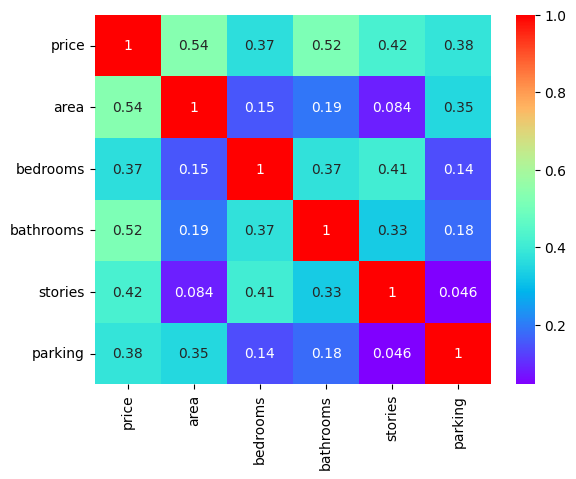

In [338]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='rainbow')
plt.show()

##### 2. Univariate Analysis

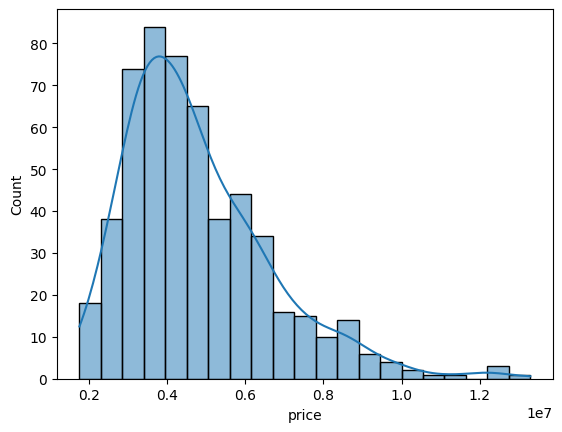

In [339]:
sns.histplot(df['price'], kde=True)
plt.show()

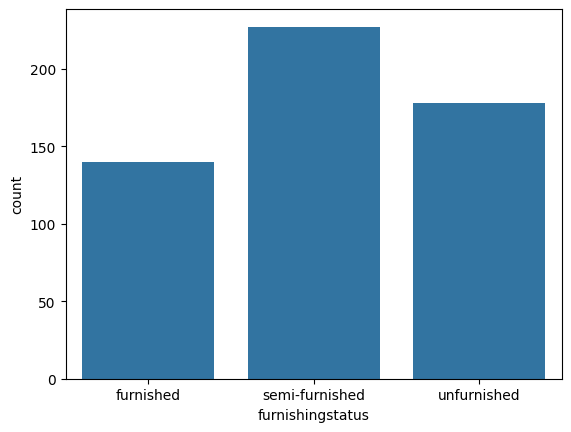

In [340]:
sns.countplot(x="furnishingstatus", data=df)
plt.show()

##### 2. Bivariate Analysis

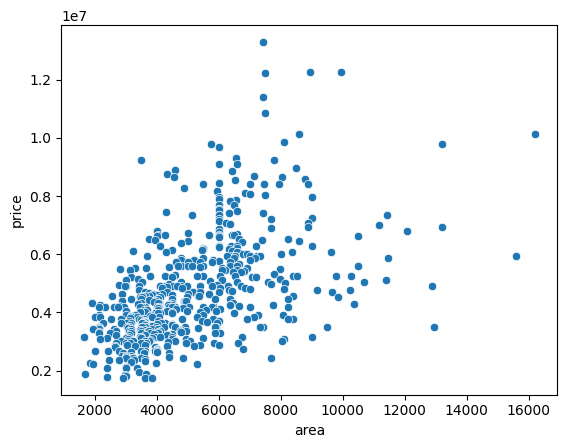

In [341]:
sns.scatterplot(x="area", y="price", data=df)
plt.show()

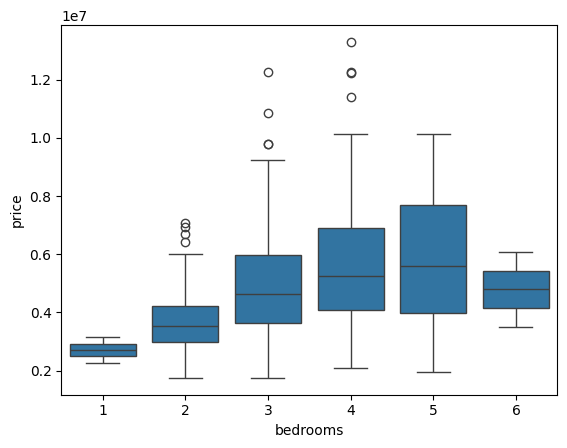

In [342]:
sns.boxplot(x="bedrooms", y="price", data=df)
plt.show()

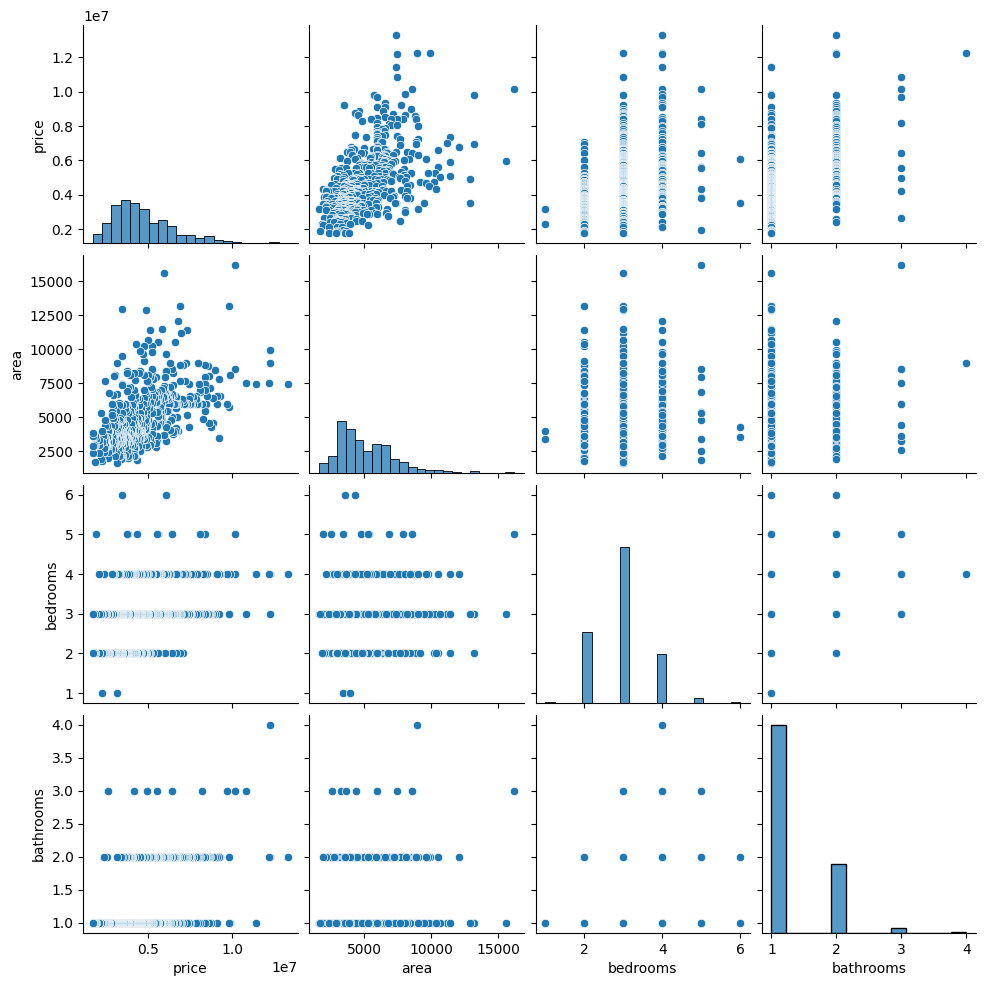

In [343]:
sns.pairplot(df[["price","area","bedrooms","bathrooms"]])
plt.show()

##### 3.Feature Engeenering

###### 1.Convert Catigorical features values into 1 and 0

In [344]:
binary_cols = ["mainroad","guestroom","basement",
               "hotwaterheating","airconditioning","prefarea"]

for col in binary_cols:
    df[col] = df[col].map({"yes":1, "no":0})

###### 2.Creating 3d scatter plot

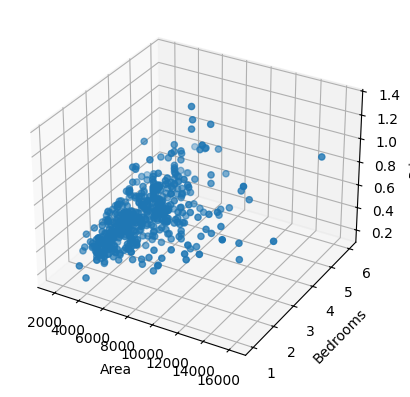

In [345]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["area"], df["bedrooms"], df["price"])

ax.set_xlabel("Area")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")

plt.show()

###### 3. One-Hot Encoding

In [346]:
df = pd.get_dummies(df, columns=["furnishingstatus"])

In [347]:
df.drop("furnishingstatus", axis=1,errors='ignore')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,False,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,True,False,False


##### 4.Linear Regression

###### 1.Train test split

In [348]:
from sklearn.model_selection import train_test_split
X = df.drop("price", axis=1)
y = df["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

###### 2.Applying Standard Scaler

In [349]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [350]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

###### 3.Model training

In [351]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [352]:
model.fit(X_train_scaled,y_train)

LinearRegression()

In [353]:
y_pred=model.predict(X_test_scaled)

###### 4.Actual vs Predicted

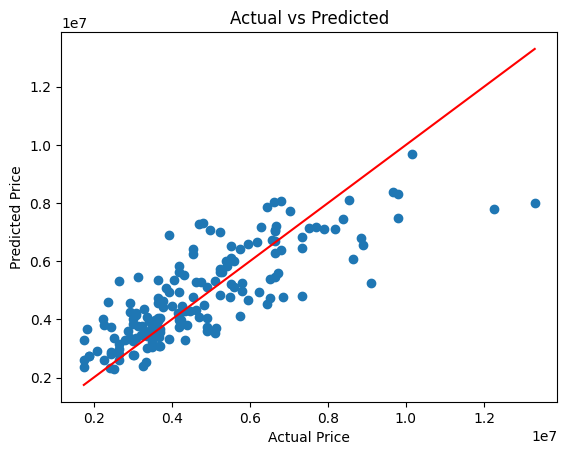

In [354]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

# line for perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

###### 5.Residual Plot

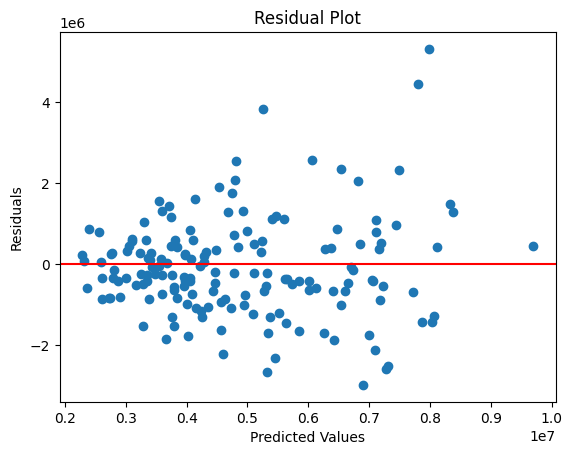

In [355]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0, color='red')
plt.show()

##### 5.Model Evaluation

In [356]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]   
p = X_test.shape[1]   

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"Adjusted R2 Score: {adj_r2:.2f}")

MSE: 1523019469501.29
RMSE: 1234106.75
MAE: 920392.94
R2 Score: 0.65
Adjusted R2 Score: 0.61


##### 5.RdigeCV Regression

In [357]:
import numpy as np
from sklearn.linear_model import RidgeCV


In [358]:
# Define alphas (regularization strengths)
alphas = np.logspace(-3, 3, 50)

# Ridge with Cross Validation
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)



RidgeCV(alphas=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-0...
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
        cv=5)

In [359]:
# Best alpha
print("Best alpha (Ridge):", ridge.alpha_)

# Prediction
y_pred_ridge = ridge.predict(X_test_scaled)



Best alpha (Ridge): 44.98432668969444


In [360]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)


n = X_test.shape[0]   
p = X_test.shape[1]   

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Ridge MSE: {mse:.2f}")
print(f"Ridge RMSE: {rmse:.2f}")
print(f"Ridge MAE: {mae:.2f}")
print(f"Ridge R2 Score: {r2:.2f}")
print(f"Ridge Adjusted R2 Score: {adj_r2:.2f}")

Ridge MSE: 1532057799159.26
Ridge RMSE: 1237763.22
Ridge MAE: 917253.71
Ridge R2 Score: 0.64
Ridge Adjusted R2 Score: 0.61


##### 6.LassoCV Regression

In [361]:
from sklearn.linear_model import LassoCV
import numpy as np


In [368]:

alphas = np.logspace(-3, 3, 50)
lasso = LassoCV(alphas=alphas, cv=5)
lasso.fit(X_train_scaled, y_train)


LassoCV(alphas=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-0...
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
        cv=5)

In [369]:

print("Best alpha (Lasso):", lasso.alpha_)
y_pred_lasso = lasso.predict(X_test_scaled)

Best alpha (Lasso): 138.9495494373136


In [370]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"LassoCV MSE: {mse:.2f}")
print(f"LassoCV RMSE: {rmse:.2f}")
print(f"LassoCV MAE: {mae:.2f}")
print(f"LassoCV R2 Score: {r2:.2f}")
print(f"LassoCV Adjusted R2 Score: {adj_r2:.2f}")


LassoCV MSE: 1523103226618.99
LassoCV RMSE: 1234140.68
LassoCV MAE: 920394.66
LassoCV R2 Score: 0.65
LassoCV Adjusted R2 Score: 0.61


In [371]:
import pandas as pd

# Model Comparison

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [1523103226618.9949, mean_squared_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_lasso)],
    'RMSE': [1234140.6834793978, np.sqrt(mean_squared_error(y_test, y_pred_ridge)), np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
    'MAE': [920394.6569810226, mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_lasso)],
    'R2 Score': [0.6463156383984522, r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
})

print(comparison_df)

               Model           MSE          RMSE            MAE  R2 Score
0  Linear Regression  1.523103e+12  1.234141e+06  920394.656981  0.646316
1   Ridge Regression  1.532058e+12  1.237763e+06  917253.714386  0.644236
2   Lasso Regression  1.523103e+12  1.234141e+06  920394.656981  0.646316
